<a href="https://colab.research.google.com/github/190yenz406/UTS-ANREG-SANAH-24/blob/main/UTS_anregril.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INPUT DATA

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, linregress, shapiro
import statsmodels.api as sm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


df = pd.read_csv('/content/bodyfat (1).csv')
Abdomen = "Abdomen"
BodyFat = "BodyFat"
display(df[[BodyFat, Abdomen]].head())


,BodyFat,Abdomen
0,12.3,85.2
1,6.1,83.0
2,25.3,87.9
3,10.4,86.4
4,28.7,100.0


PEMBERSIHAN DATA

In [2]:
# Jumlah missing values
total_missing_now = df.isnull().sum().sum()
print(f"Jumlah total missing values saat ini: {total_missing_now}")

# Jumlah duplikasi
total_duplicates_now = df.duplicated().sum()
print(f"Jumlah total data duplikasi saat ini: {total_duplicates_now}")

# Jumlah outlier
# Kolom yang ingin dicek outlier-nya
selected_cols = [Abdomen, BodyFat]

print("Jumlah outlier untuk Abdomen dan BodyFat:")
for col in selected_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"  {col}: {len(outliers)}")

Jumlah total missing values saat ini: 0
Jumlah total data duplikasi saat ini: 0
Jumlah outlier untuk Abdomen dan BodyFat:
  Abdomen: 3
  BodyFat: 1


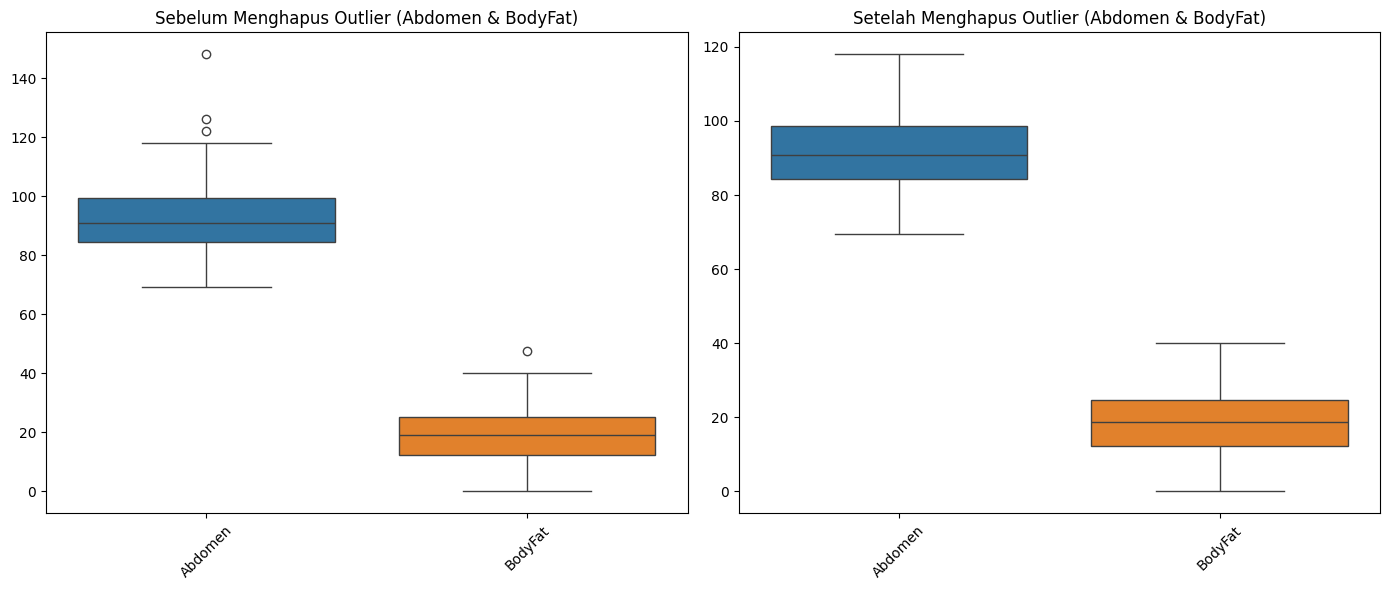


Data berhasil dibersihkan.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def remove_outliers_iqr(df_param, columns):
    df_clean = df_param.copy()

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)  # Kuartil pertama (Q1)
        Q3 = df_clean[col].quantile(0.75)  # Kuartil ketiga (Q3)
        IQR = Q3 - Q1  # Interquartile Range (IQR)

        lower_bound = Q1 - 1.5 * IQR  # Batas bawah
        upper_bound = Q3 + 1.5 * IQR  # Batas atas

        # Hanya mempertahankan data yang berada dalam batas IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    return df_clean

# Membersihkan data dari outlier (menggunakan semua kolom numerik untuk proses pembersihan)
numeric_cols_all = df.select_dtypes(include=[np.number]).columns
cleaned_data = remove_outliers_iqr(df, numeric_cols_all)

# Membuat Boxplot sebelum dan sesudah menghapus outlier untuk kolom yang dipilih
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot sebelum pembersihan
sns.boxplot(data=df[selected_cols], ax=axes[0])
axes[0].set_title("Sebelum Menghapus Outlier (Abdomen & BodyFat)")
axes[0].set_xticks(range(len(selected_cols)))
axes[0].set_xticklabels(selected_cols, rotation=45)

# Boxplot setelah pembersihan
sns.boxplot(data=cleaned_data[selected_cols], ax=axes[1])
axes[1].set_title("Setelah Menghapus Outlier (Abdomen & BodyFat)")
axes[1].set_xticks(range(len(selected_cols)))
axes[1].set_xticklabels(selected_cols, rotation=45)

plt.tight_layout()
plt.show()

print("\nData berhasil dibersihkan.")

STATISTIK DESKRIPTIF

In [4]:
print("\nStatistik Deskriptif:")
print(df[['BodyFat', 'Abdomen']].describe())

BodyFat_cleaned_array = df[BodyFat].values
Abdomen_cleaned_array = df[Abdomen].values



Statistik Deskriptif:
          BodyFat     Abdomen
count  252.000000  252.000000
mean    19.150794   92.555952
std      8.368740   10.783077
min      0.000000   69.400000
25%     12.475000   84.575000
50%     19.200000   90.950000
75%     25.300000   99.325000
max     47.500000  148.100000


ANALISIS REGRESI LINEAR SEDERHANA

interpretasi korelasi antara abdomen dan body fat

Interpretasi: Korelasi sangat kuat positif


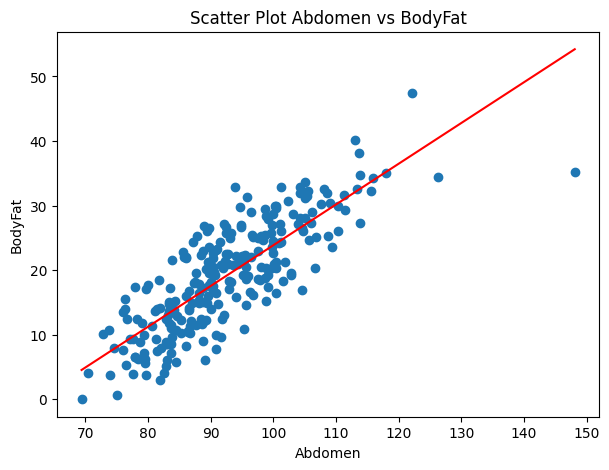

In [5]:
korelasi_pearson, p_value = pearsonr(BodyFat_cleaned_array, BodyFat_cleaned_array)
# Interpretasi hasil
if korelasi_pearson > 0.8:
  interpretasi = "Korelasi sangat kuat positif"
elif korelasi_pearson > 0.6:
  interpretasi = "Korelasi kuat positif"
elif korelasi_pearson > 0.4:
  interpretasi = "Korelasi sedang positif"
elif korelasi_pearson > 0.2:
  interpretasi = "Korelasi lemah positif"
elif korelasi_pearson > 0:
  interpretasi = "Korelasi sangat lemah positif"
elif korelasi_pearson < -0.8:
  interpretasi = "Korelasi sangat kuat negatif"
elif korelasi_pearson < -0.6:
  interpretasi = "Korelasi kuat negatif"
elif korelasi_pearson < -0.4:
  interpretasi = "Korelasi sedang negatif"
elif korelasi_pearson < -0.2:
  interpretasi = "Korelasi lemah negatif"
elif korelasi_pearson < 0:
  interpretasi = "Korelasi sangat lemah negatif"
else: interpretasi = "Tidak ada korelasi linier (atau sangat mendekati nol)"

print(f"Interpretasi: {interpretasi}")



#SCATTERPLOT DENGAN GARIS REGRESI
X_ols = sm.add_constant(df[Abdomen])
y_ols = df[BodyFat]
model = sm.OLS(y_ols, X_ols).fit()

plt.figure(figsize=(7,5))
plt.scatter(df[Abdomen], df[BodyFat])

slope_linregress, intercept_linregress, _, _, _ = linregress(df[Abdomen], df[BodyFat])
X_line = np.linspace(df[Abdomen].min(), df[Abdomen].max(), 100)
Y_line = intercept_linregress + slope_linregress * X_line
plt.plot(X_line, Y_line, color='red')

plt.xlabel(Abdomen)
plt.ylabel(BodyFat)
plt.title(f"Scatter Plot {Abdomen} vs {BodyFat}")
plt.show()

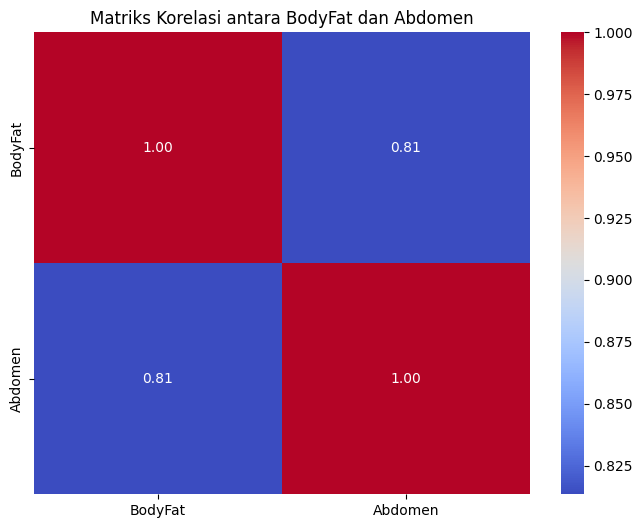

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[[BodyFat, Abdomen]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriks Korelasi antara BodyFat dan Abdomen")
plt.show()

 Model regresi linear sederhana dan interpretasi koefisien

In [7]:
intercept = model.params['const']
slope = model.params[Abdomen]
print(f"Persamaan Regresi: {BodyFat} = {round(intercept,2)} + {round(slope,2)} * {Abdomen}\n")

print("Interpretasi:")
print(f"1. Intercept (β0 = {round(intercept,2)}):")
print(f"   Nilai {BodyFat} ketika {Abdomen} = 0 adalah {round(intercept,2)} poin \n")

print(f"2. Slope (β1 = {round(slope,2)}):")
print(f"   Setiap penambahan 1 unit {Abdomen}, nilai {BodyFat} berubah sebesar {round(slope,2)} poin")

Persamaan Regresi: BodyFat = -39.28 + 0.63 * Abdomen

Interpretasi:
1. Intercept (β0 = -39.28):
   Nilai BodyFat ketika Abdomen = 0 adalah -39.28 poin 

2. Slope (β1 = 0.63):
   Setiap penambahan 1 unit Abdomen, nilai BodyFat berubah sebesar 0.63 poin


UJI ASUMSI KLASIK

1. UJI NORMALITAS (Shapiro-Wilk Test)


--- Uji Normalitas (Shapiro-Wilk Test) ---
Hasil Uji Shapiro-Wilk: Statistik = 0.991, P-value = 0.147

Hipotesis Nol (H0): Residual berdistribusi normal.
Keputusan: Gagal menolak H0. Residual berdistribusi normal.


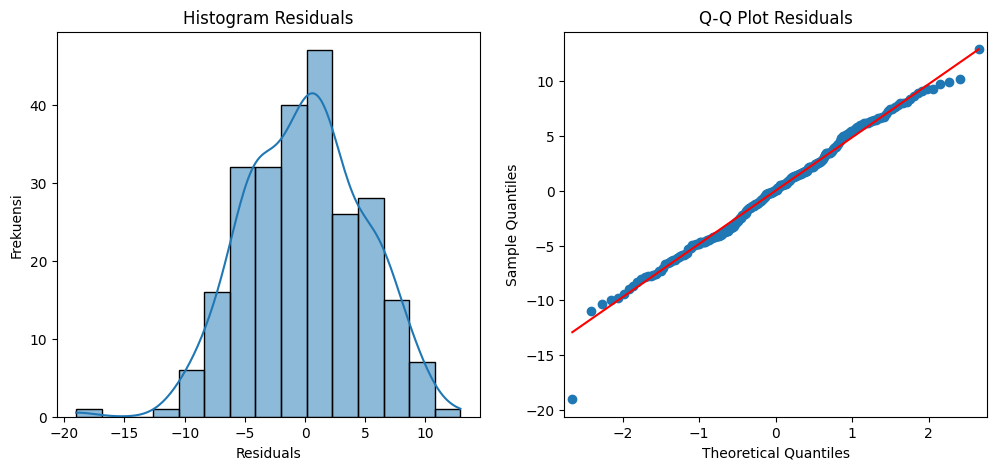

In [8]:
from scipy.stats import shapiro
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# definisikan X_ols, y_ols, dan model
X_ols = sm.add_constant(df[Abdomen])
y_ols = df[BodyFat]
model = sm.OLS(y_ols, X_ols).fit()
# Calculate residuals
residuals = model.resid

print("\n--- Uji Normalitas (Shapiro-Wilk Test) ---")

# Perform Shapiro-Wilk Test
stat, p = shapiro(residuals)
print(f'Hasil Uji Shapiro-Wilk: Statistik = {stat:.3f}, P-value = {p:.3f}')

print("\nHipotesis Nol (H0): Residual berdistribusi normal.")


if p > 0.05:
    print('Keputusan: Gagal menolak H0. Residual berdistribusi normal.')
else:
    print('Keputusan: Tolak H0. Residual tidak berdistribusi normal.')

# Plot
fig, ax = plt.subplots(1,2, figsize=(12,5))

# Histogram
sns.histplot(residuals, kde=True, ax=ax[0])
ax[0].set_title('Histogram Residuals')
ax[0].set_xlabel('Residuals')
ax[0].set_ylabel('Frekuensi')

# QQ Plot
sm.qqplot(residuals, line='s', ax=ax[1])
ax[1].set_title('Q-Q Plot Residuals')

plt.show()

2. Uji Heteroskedastisitas (Goldfeld-Quandt Test)

In [9]:
from statsmodels.stats.api import het_goldfeldquandt

print("\n--- Uji Heteroskedastisitas (Goldfeld-Quandt Test) ---")
gq_test = het_goldfeldquandt(model.resid, model.model.exog[:, 1].reshape(-1, 1))

labels_gq = ['F-statistic', 'P-value']
print(f'Hasil Uji Goldfeld-Quandt: F-statistic = {gq_test[0]:.3f}, P-value = {gq_test[1]:.3f}')

print("\nHipotesis Nol (H0): Tidak ada heteroskedastisitas (homoskedastisitas).")

# Interpretasi hasil Uji Goldfeld-Quandt (menggunakan p-value)
if gq_test[1] > 0.05:
    print('Keputusan: Gagal tolak H0. Tidak ada heteroskedastisitas (homoskedastisitas).')
else:
    print('Keputusan: Tolak H0. Terdapat heteroskedastisitas.')


--- Uji Heteroskedastisitas (Goldfeld-Quandt Test) ---
Hasil Uji Goldfeld-Quandt: F-statistic = 0.892, P-value = 0.738

Hipotesis Nol (H0): Tidak ada heteroskedastisitas (homoskedastisitas).
Keputusan: Gagal tolak H0. Tidak ada heteroskedastisitas (homoskedastisitas).


3. Uji Autokorelasi (Durbin-Watson Test)

In [10]:
from statsmodels.stats.stattools import durbin_watson

print("\n--- Uji Autokorelasi (Durbin-Watson Test) ---")
dw_statistic = durbin_watson(residuals)
print(f'Statistik Durbin-Watson: {dw_statistic:.3f}')

print("\nHipotesis Nol (H0): Tidak ada autokorelasi.")

if 1.5 < dw_statistic < 2.5:
    print('Keputusan: Gagal tolak H0. Tidak ada autokorelasi.')
elif dw_statistic <= 1.5:
    print('Keputusan: Tolak H0. Terdapat autokorelasi positif.')
else:
    print('Keputusan: Gagal Tolak H0. Terdapat autokorelasi negatif.')


--- Uji Autokorelasi (Durbin-Watson Test) ---
Statistik Durbin-Watson: 1.811

Hipotesis Nol (H0): Tidak ada autokorelasi.
Keputusan: Gagal tolak H0. Tidak ada autokorelasi.


Uji Signifikansi Koefisien Regresi (Uji t)

In [11]:
# Hitung koefisien korelasi Pearson dan p-value
alpha = 0.05
print(f"P-value antara Variabel X ({Abdomen}) dan Variabel Y ({BodyFat}): {p_value:.3f}")
print(f"Tingkat Signifikansi (alpha): {alpha}")


#Lakukan uji hipotesis
print("\nHipotesis Nol (H0): Tidak ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Abdomen dan BodyFat dalam populasi.")
if p_value < alpha:
  keputusan = "Tolak Hipotesis Nol (H0)"
  interpretasi_uji = "Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Abdomen dan Body Fat dalam populasi."
else:
  keputusan = "Gagal Menolak Hipotesis Nol (H0)"
  interpretasi_uji = "Tidak ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Abdomen dan Body Fat dalam populasi."

print(f"\nKeputusan: {keputusan}")
print(f"Interpretasi Uji: {interpretasi_uji}")

P-value antara Variabel X (Abdomen) dan Variabel Y (BodyFat): 0.000
Tingkat Signifikansi (alpha): 0.05

Hipotesis Nol (H0): Tidak ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Abdomen dan BodyFat dalam populasi.

Keputusan: Tolak Hipotesis Nol (H0)
Interpretasi Uji: Ada bukti statistik yang cukup untuk menyimpulkan adanya hubungan linier yang signifikan antara Abdomen dan Body Fat dalam populasi.


EVALUASI MODEL

Ringkasan Model

In [12]:
X_ols = sm.add_constant(df[Abdomen])
y_ols = df[BodyFat]
model = sm.OLS(y_ols, X_ols).fit()

print("Ringkasan model:")
print(model.summary())


Ringkasan model:
                            OLS Regression Results                            
Dep. Variable:                BodyFat   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     488.9
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           9.09e-61
Time:                        13:08:01   Log-Likelihood:                -755.90
No. Observations:                 252   AIC:                             1516.
Df Residuals:                     250   BIC:                             1523.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -39.2802      2.660   

Memprediksi body fat

MAE: 3.9163099617386496
R2: 0.6616720819241175
   Abdomen  BodyFat_Asli  BodyFat_Prediksi
0     85.2          12.3         14.506949
1     83.0           6.1         13.118079
2     87.9          25.3         16.211471
3     86.4          10.4         15.264514
4    100.0          28.7         23.850254


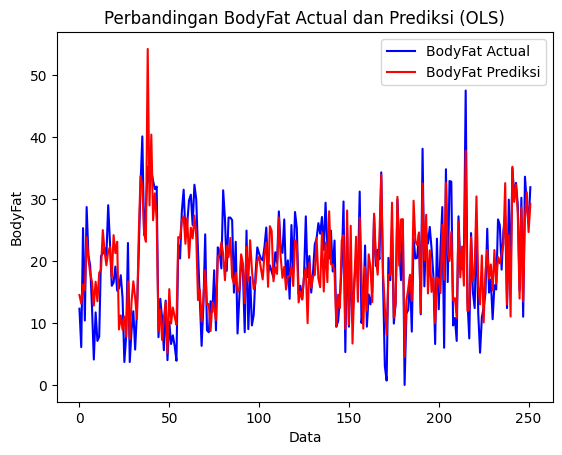

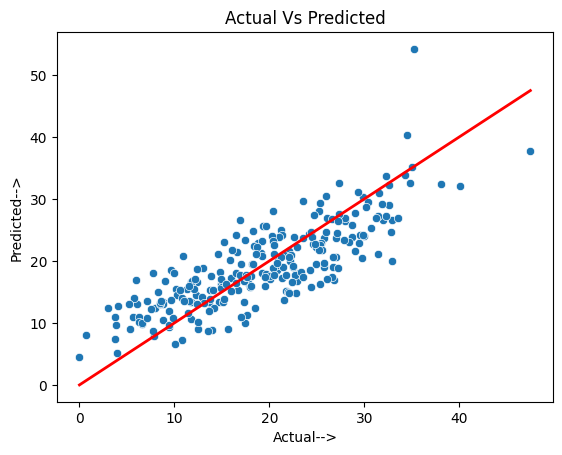

In [13]:

# Prediksi Body Fat
y_pred = model.predict(X_ols)

# Evaluasi
mae = mean_absolute_error(y_ols, y_pred)
r2 = r2_score(y_ols, y_pred)

hasil_prediksi = pd.DataFrame({
    "Abdomen": df[Abdomen],
    "BodyFat_Asli": y_ols,
    "BodyFat_Prediksi": y_pred
})

print("MAE:", mae)
print("R2:", r2)
print(hasil_prediksi.head())


# Grafik perbandingan
plt.figure()

plt.plot(y_ols.values, label="BodyFat Actual", color="blue")
plt.plot(y_pred.values, label="BodyFat Prediksi", color="red")

plt.title("Perbandingan BodyFat Actual dan Prediksi (OLS)")
plt.xlabel("Data")
plt.ylabel("BodyFat")
plt.legend()
plt.show()

#Linearitas antara Bodyfat actual dan prediksi
sns.scatterplot(x=y_ols, y=y_pred)
plt.plot([y_ols.min(), y_ols.max()], [y_ols.min(), y_ols.max()], color = 'Red',linestyle='-',linewidth=2)
plt.xlabel("Actual-->")
plt.ylabel("Predicted-->")
plt.title("Actual Vs Predicted")
plt.show()